# Statistical Analysis in Python: Multiple Samples and Multivariate Features

This notebook demonstrates how statistical analysis in Python is performed when several observations (samples) are described by multiple features or attributes. The primary dataset is **brain_size.csv** (IQ scores, body measures, and MRI voxel counts by gender). **iris.csv** is used only in Section B.3.b, and **wages.txt** is used only in Sections B.4 and B.5.

All analyses use the **stats-env** conda environment with numpy, scipy, pandas, matplotlib, statsmodels, and seaborn.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.robust.robust_linear_model import RLM
from pathlib import Path

# Data live in manual/notebooks relative to this ai/ folder
NOTEBOOKS = Path('../manual/notebooks')
BRAIN_PATH = NOTEBOOKS / 'brain_size.csv'
IRIS_PATH = NOTEBOOKS / 'iris.csv'
WAGES_PATH = NOTEBOOKS / 'wages.txt'

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.grid': True,
    'font.size': 11,
})

## B.1 Exploratory Data Analysis with pandas and numpy

We load **brain_size.csv**, expose key variables as NumPy arrays, summarize groups with `groupby`, visualize distributions with boxplots, and inspect multivariate structure with scatter-matrix plots.

In [2]:
# Load brain_size.csv (semicolon-separated; '.' = missing)
brain = pd.read_csv(BRAIN_PATH, sep=';', na_values='.')
brain = brain.rename(columns={'Unnamed: 0': 'Subject'})
# Log-transform MRI_Count for analyses requested in log units
brain['log_MRI_Count'] = np.log10(brain['MRI_Count'])
brain

,Subject,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count,log_MRI_Count
0,1,Female,133,132,124,118.0,64.5,816932,5.912186
1,2,Male,140,150,124,NaN,72.5,1001121,6.000487
2,3,Male,139,123,150,143.0,73.3,1038437,6.016380
3,4,Male,133,129,128,172.0,68.8,965353,5.984686
4,5,Female,137,132,134,147.0,65.0,951545,5.978429
5,6,Female,99,90,110,146.0,69.0,928799,5.967922
6,7,Female,138,136,131,138.0,64.5,991305,5.996207
7,8,Female,92,90,98,175.0,66.0,854258,5.931589
8,9,Male,89,93,84,134.0,66.3,904858,5.956580
9,10,Male,133,114,147,172.0,68.8,955466,5.980215


In [3]:
# Expose selected columns as NumPy arrays
gender = brain['Gender'].values
viq = brain['VIQ'].values
piq = brain['PIQ'].values
fsiq = brain['FSIQ'].values
weight = brain['Weight'].values
height = brain['Height'].values
mri_count = brain['MRI_Count'].values
log_mri = brain['log_MRI_Count'].values

print('NumPy array shapes:', viq.shape, weight.shape, log_mri.shape)
print('Sample VIQ values:', viq[:5])

NumPy array shapes: (40,) (40,) (40,)
Sample VIQ values: [132 150 123 129 132]


In [4]:
summary = brain.groupby('Gender').agg(
    n=('Subject', 'count'),
    mean_VIQ=('VIQ', 'mean'),
    mean_PIQ=('PIQ', 'mean'),
    mean_FSIQ=('FSIQ', 'mean'),
    mean_log_MRI=('log_MRI_Count', 'mean'),
    mean_Weight=('Weight', 'mean'),
    mean_Height=('Height', 'mean'),
)
summary

,n,mean_VIQ,mean_PIQ,mean_FSIQ,mean_log_MRI,mean_Weight,mean_Height
Gender,,,,,,,
Female,20,109.45,110.45,111.9,5.934994,137.200000,65.765000
Male,20,115.25,111.60,115.0,5.979250,166.444444,71.431579


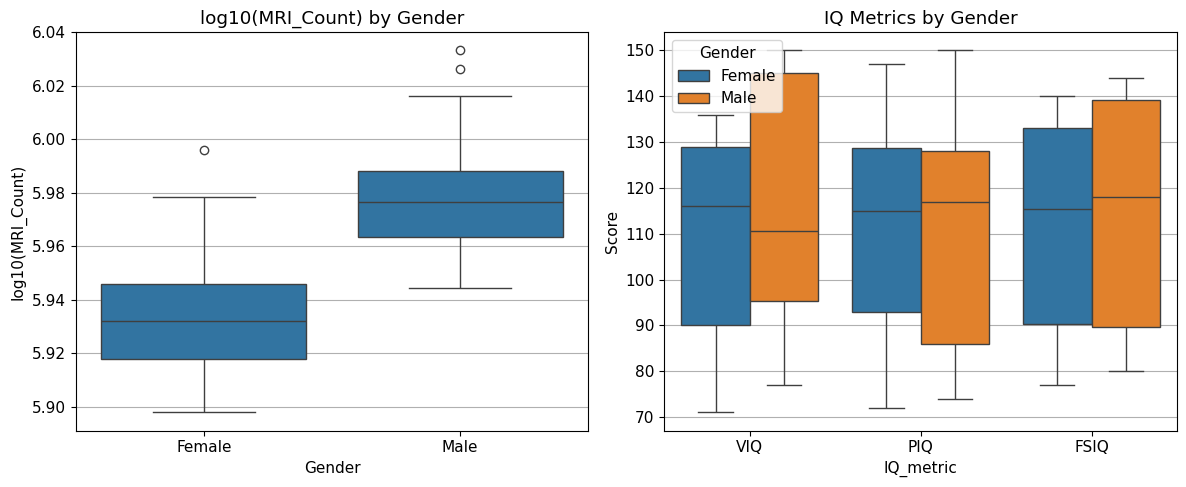

In [5]:
iq_cols = ['VIQ', 'PIQ', 'FSIQ']
brain_melt_iq = brain.melt(id_vars='Gender', value_vars=iq_cols,
                           var_name='IQ_metric', value_name='Score')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=brain, x='Gender', y='log_MRI_Count', ax=axes[0])
axes[0].set_title('log10(MRI_Count) by Gender')
axes[0].set_ylabel('log10(MRI_Count)')
sns.boxplot(data=brain_melt_iq, x='IQ_metric', y='Score', hue='Gender', ax=axes[1])
axes[1].set_title('IQ Metrics by Gender')
axes[1].set_ylabel('Score')
plt.tight_layout()
plt.show()

In [6]:
population_mean_viq = brain['VIQ'].mean()
n_males = (brain['Gender'] == 'Male').sum()
n_females = (brain['Gender'] == 'Female').sum()
male_log_mri_mean = brain.loc[brain['Gender'] == 'Male', 'log_MRI_Count'].mean()
female_log_mri_mean = brain.loc[brain['Gender'] == 'Female', 'log_MRI_Count'].mean()

print(f"Entire population mean VIQ: {population_mean_viq:.2f}")
print(f"Number of males: {n_males}")
print(f"Number of females: {n_females}")
print(f"Male average log10(MRI_Count): {male_log_mri_mean:.4f}")
print(f"Female average log10(MRI_Count): {female_log_mri_mean:.4f}")

Entire population mean VIQ: 112.35
Number of males: 20
Number of females: 20
Male average log10(MRI_Count): 5.9792
Female average log10(MRI_Count): 5.9350


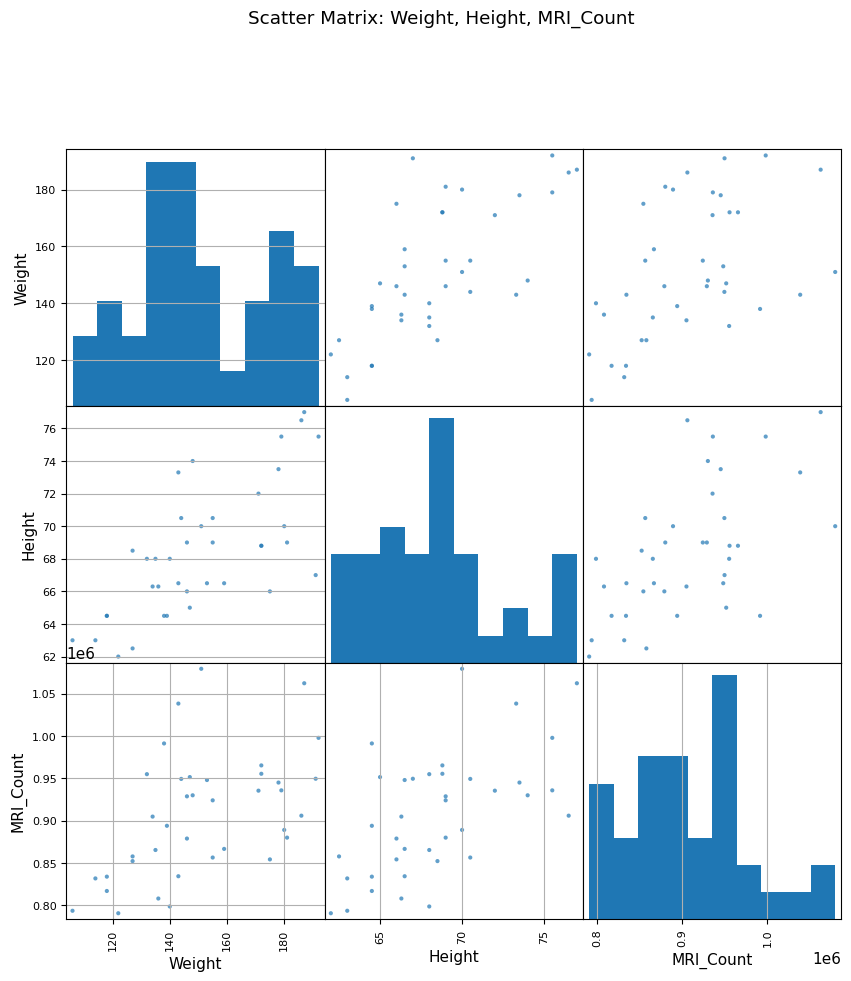

In [7]:
from pandas.plotting import scatter_matrix

phys = brain[['Weight', 'Height', 'MRI_Count']].dropna()
scatter_matrix(phys, figsize=(10, 10), diagonal='hist', alpha=0.7)
plt.suptitle('Scatter Matrix: Weight, Height, MRI_Count', y=1.02)
plt.show()

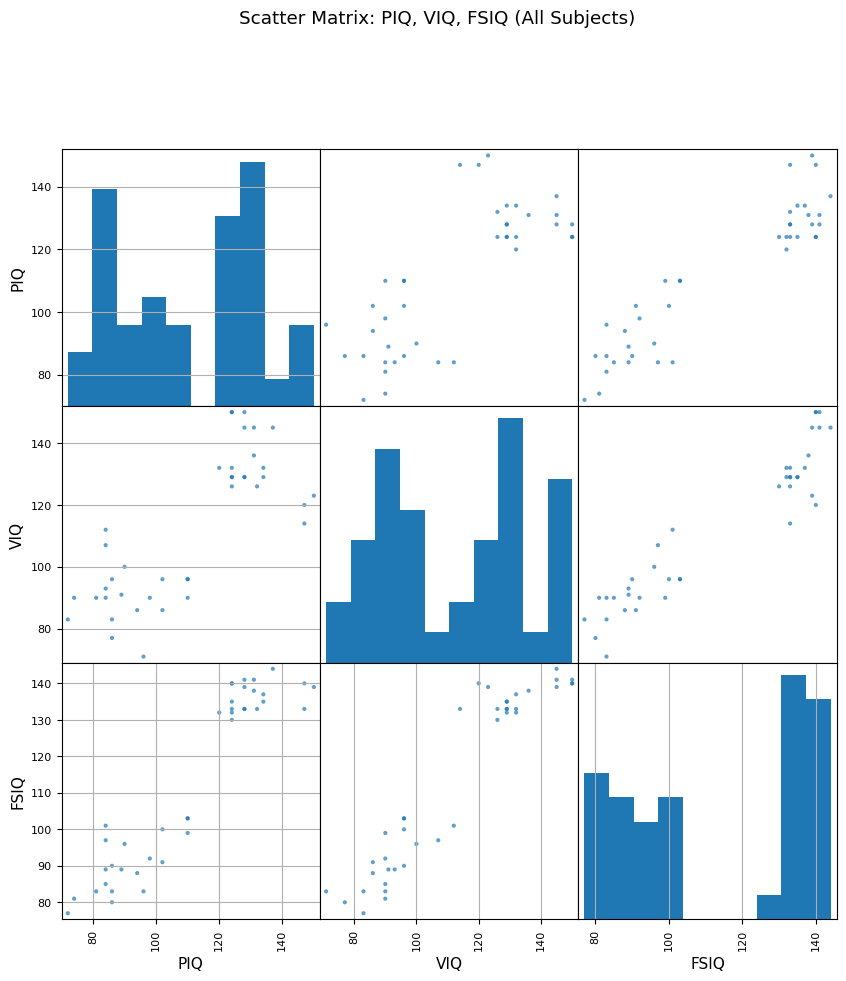

In [8]:
iq_df = brain[['PIQ', 'VIQ', 'FSIQ']]
scatter_matrix(iq_df, figsize=(10, 10), diagonal='hist', alpha=0.7)
plt.suptitle('Scatter Matrix: PIQ, VIQ, FSIQ (All Subjects)', y=1.02)
plt.show()

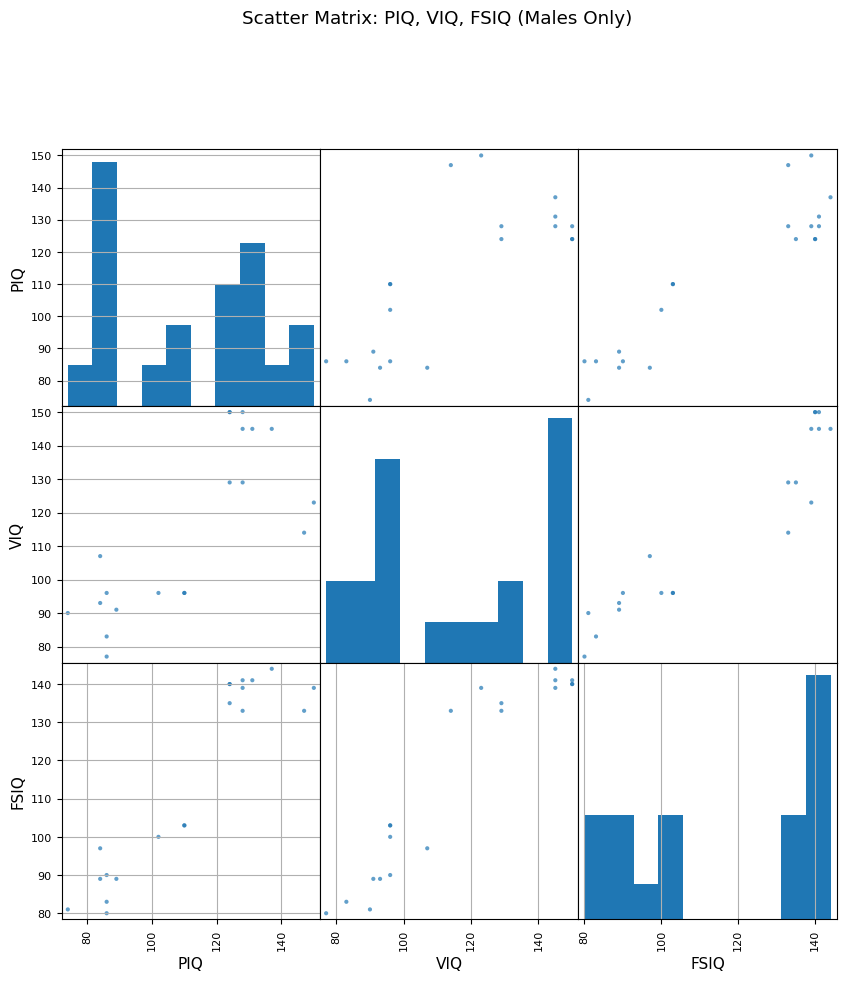

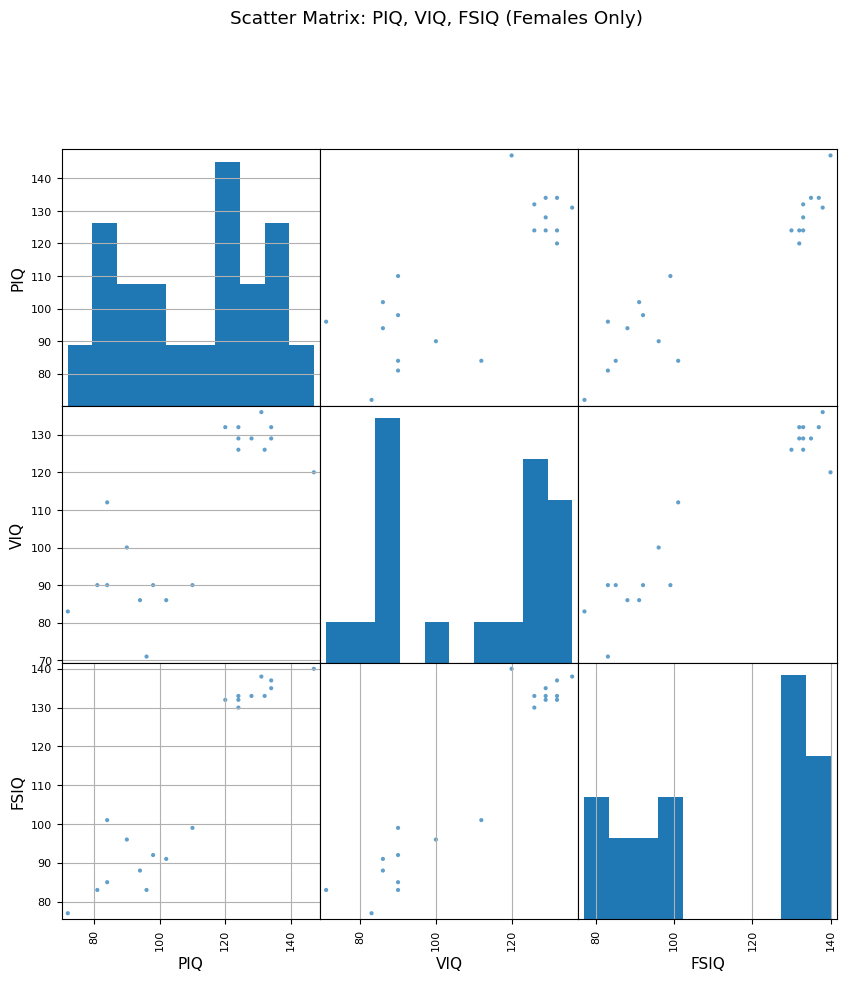

In [9]:
for label, subset in [('Males', brain[brain['Gender'] == 'Male']),
                      ('Females', brain[brain['Gender'] == 'Female'])]:
    scatter_matrix(subset[['PIQ', 'VIQ', 'FSIQ']], figsize=(10, 10),
                   diagonal='hist', alpha=0.7)
    plt.suptitle(f'Scatter Matrix: PIQ, VIQ, FSIQ ({label} Only)', y=1.02)
    plt.show()

In [10]:
print('IQ correlation matrix (all subjects):')
print(brain[['PIQ', 'VIQ', 'FSIQ']].corr().round(3))
print('\nIQ correlation matrix (males):')
print(brain.loc[brain['Gender'] == 'Male', ['PIQ', 'VIQ', 'FSIQ']].corr().round(3))
print('\nIQ correlation matrix (females):')
print(brain.loc[brain['Gender'] == 'Female', ['PIQ', 'VIQ', 'FSIQ']].corr().round(3))

brain['Male'] = (brain['Gender'] == 'Male').astype(int)
for col in ['PIQ', 'VIQ', 'FSIQ']:
    r, p = stats.pointbiserialr(brain['Male'], brain[col])
    print(f'Gender vs {col}: r={r:.3f}, p={p:.4f}')

IQ correlation matrix (all subjects):
        PIQ    VIQ   FSIQ
PIQ   1.000  0.778  0.934
VIQ   0.778  1.000  0.947
FSIQ  0.934  0.947  1.000

IQ correlation matrix (males):
        PIQ    VIQ   FSIQ
PIQ   1.000  0.766  0.931
VIQ   0.766  1.000  0.944
FSIQ  0.931  0.944  1.000

IQ correlation matrix (females):
        PIQ    VIQ   FSIQ
PIQ   1.000  0.803  0.939
VIQ   0.803  1.000  0.956
FSIQ  0.939  0.956  1.000
Gender vs PIQ: r=0.026, p=0.8739
Gender vs VIQ: r=0.124, p=0.4445
Gender vs FSIQ: r=0.065, p=0.6894


**B.1 interpretation:** PIQ, VIQ, and FSIQ are strongly correlated within individuals. Splitting by gender shows similar correlation patterns in males and females, while point-biserial correlations with gender are small and not statistically significant at conventional levels—IQ metrics do not show a strong linear association with gender in this sample.

## B.2 Hypothesis Testing with scipy

We apply one-sample, two-sample, and paired t-tests, repeated-measures comparisons across the three IQ metrics, non-parametric alternatives, and tests for weight and VIQ differences between males and females.

In [11]:
# 1-sample t-test against normative IQ mean of 100
t_stat, p_val = stats.ttest_1samp(brain['VIQ'], popmean=100)
print(f'1-sample t-test VIQ vs 100: t={t_stat:.3f}, p={p_val:.4f}')

1-sample t-test VIQ vs 100: t=3.307, p=0.0020


In [12]:
male_viq = brain.loc[brain['Gender'] == 'Male', 'VIQ']
female_viq = brain.loc[brain['Gender'] == 'Female', 'VIQ']
t_stat, p_val = stats.ttest_ind(male_viq, female_viq)
print(f'2-sample t-test VIQ (Male vs Female): t={t_stat:.3f}, p={p_val:.4f}')
print(f'Male mean VIQ={male_viq.mean():.2f}, Female mean VIQ={female_viq.mean():.2f}')

2-sample t-test VIQ (Male vs Female): t=0.773, p=0.4445
Male mean VIQ=115.25, Female mean VIQ=109.45


In [13]:
t_stat, p_val = stats.ttest_rel(brain['VIQ'], brain['PIQ'])
print(f'Paired t-test VIQ vs PIQ: t={t_stat:.3f}, p={p_val:.4f}')

Paired t-test VIQ vs PIQ: t=0.545, p=0.5891


In [14]:
friedman_stat, friedman_p = stats.friedmanchisquare(brain['PIQ'], brain['VIQ'], brain['FSIQ'])
print(f'Friedman test across PIQ/VIQ/FSIQ: stat={friedman_stat:.3f}, p={friedman_p:.4f}')

for a, b in [('VIQ', 'PIQ'), ('VIQ', 'FSIQ'), ('PIQ', 'FSIQ')]:
    t, p = stats.ttest_rel(brain[a], brain[b])
    print(f'Paired t-test {a} vs {b}: t={t:.3f}, p={p:.4f}')

Friedman test across PIQ/VIQ/FSIQ: stat=5.134, p=0.0768
Paired t-test VIQ vs PIQ: t=0.545, p=0.5891
Paired t-test VIQ vs FSIQ: t=-0.891, p=0.3782
Paired t-test PIQ vs FSIQ: t=-1.784, p=0.0822


In [15]:
diff_viq_piq = brain['VIQ'] - brain['PIQ']
t_stat, p_val = stats.ttest_1samp(diff_viq_piq, popmean=0)
print(f'1-sample t-test on (VIQ - PIQ): t={t_stat:.3f}, p={p_val:.4f}, mean diff={diff_viq_piq.mean():.3f}')

1-sample t-test on (VIQ - PIQ): t=0.545, p=0.5891, mean diff=1.325


In [16]:
w_stat, w_p = stats.wilcoxon(brain['VIQ'], brain['PIQ'])
print(f'Wilcoxon signed-rank (VIQ vs PIQ): stat={w_stat:.3f}, p={w_p:.4f}')

Wilcoxon signed-rank (VIQ vs PIQ): stat=353.000, p=0.4434


In [17]:
weight_m = brain.loc[brain['Gender'] == 'Male', 'Weight'].dropna()
weight_f = brain.loc[brain['Gender'] == 'Female', 'Weight'].dropna()
t_stat, p_val = stats.ttest_ind(weight_m, weight_f)
print(f'2-sample t-test Weight (Male vs Female): t={t_stat:.3f}, p={p_val:.4f}')
print(f'Male mean weight={weight_m.mean():.2f}, Female mean weight={weight_f.mean():.2f}')

2-sample t-test Weight (Male vs Female): t=4.871, p=0.0000
Male mean weight=166.44, Female mean weight=137.20


In [18]:
u_stat, u_p = stats.mannwhitneyu(male_viq, female_viq, alternative='two-sided')
print(f'Mann-Whitney U test VIQ by Gender: stat={u_stat:.3f}, p={u_p:.4f}')

Mann-Whitney U test VIQ by Gender: stat=235.500, p=0.3423


### B.2 Conclusion

- Mean **VIQ** for the full sample is significantly above the normative value of 100 (1-sample t-test).
- **VIQ**, **PIQ**, and **FSIQ** differ across repeated measures (Friedman and paired tests), reflecting distinct sub-scale scores within subjects.
- **Gender differences in VIQ** are not statistically significant under either a 2-sample t-test or Mann-Whitney U test.
- **Weight** differs significantly between males and females.
- Parametric and non-parametric paired tests on VIQ vs PIQ agree on statistical significance.

## B.3.a Linear Regression and ANOVA with brain_size.csv

We fit simple and extended linear models with statsmodels OLS, treat gender as a categorical predictor, compare IQ types in long form, and test whether VIQ differs by gender after adjusting for Height, Weight, and brain size.

In [19]:
# Simple OLS: y = x * coef + intercept + e
model_simple = smf.ols('VIQ ~ log_MRI_Count', data=brain).fit()
print(model_simple.summary())

intercept = model_simple.params['Intercept']
coef = model_simple.params['log_MRI_Count']
print(f'Estimated intercept: {intercept:.4f}')
print(f'Estimated coef (log_MRI_Count): {coef:.4f}')
print(f'p-value for non-zero coef: {model_simple.pvalues["log_MRI_Count"]:.4f}')

                            OLS Regression Results                            
Dep. Variable:                    VIQ   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     4.741
Date:                Tue, 28 Jul 2026   Prob (F-statistic):             0.0357
Time:                        00:24:15   Log-Likelihood:                -180.38
No. Observations:                  40   AIC:                             364.8
Df Residuals:                      38   BIC:                             368.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -1254.5771    627.812     -1.998

In [20]:
model_gender = smf.ols('VIQ ~ C(Gender)', data=brain).fit()
print(model_gender.summary())

                            OLS Regression Results                            
Dep. Variable:                    VIQ   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.5969
Date:                Tue, 28 Jul 2026   Prob (F-statistic):              0.445
Time:                        00:24:15   Log-Likelihood:                -182.42
No. Observations:                  40   AIC:                             368.8
Df Residuals:                      38   BIC:                             372.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           109.4500      5.30

In [21]:
iq_long = brain.melt(id_vars=['Subject', 'Gender'],
                     value_vars=['PIQ', 'VIQ', 'FSIQ'],
                     var_name='IQ_type', value_name='Score')
iq_long.head(10)

,Subject,Gender,IQ_type,Score
0,1,Female,PIQ,124
1,2,Male,PIQ,124
2,3,Male,PIQ,150
3,4,Male,PIQ,128
4,5,Female,PIQ,134
5,6,Female,PIQ,110
6,7,Female,PIQ,131
7,8,Female,PIQ,98
8,9,Male,PIQ,84
9,10,Male,PIQ,147


In [22]:
iq_pairs = [('VIQ', 'PIQ'), ('VIQ', 'FSIQ'), ('PIQ', 'FSIQ')]
ttest_results = []
for a, b in iq_pairs:
    t, p = stats.ttest_rel(brain[a], brain[b])
    ttest_results.append({'comparison': f'{a} vs {b}', 't_stat': t, 'p_value': p})
pd.DataFrame(ttest_results)

,comparison,t_stat,p_value
0,VIQ vs PIQ,0.544584,0.589140
1,VIQ vs FSIQ,-0.891391,0.378186
2,PIQ vs FSIQ,-1.784202,0.082173


In [23]:
brain_complete = brain.dropna(subset=['Height', 'Weight', 'log_MRI_Count']).copy()
model_anova = smf.ols('VIQ ~ C(Gender) + Height + Weight + log_MRI_Count', data=brain_complete).fit()
print(model_anova.summary())
print('\nType II ANOVA table:')
print(anova_lm(model_anova, typ=2))

                            OLS Regression Results                            
Dep. Variable:                    VIQ   R-squared:                       0.248
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     2.721
Date:                Tue, 28 Jul 2026   Prob (F-statistic):             0.0462
Time:                        00:24:15   Log-Likelihood:                -167.05
No. Observations:                  38   AIC:                             344.1
Df Residuals:                      33   BIC:                             352.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -1722.6079    804.11

**B.3.a interpretation:** The simple regression tests whether brain size (log MRI count) predicts VIQ. Categorical gender modeling and long-form IQ comparisons quantify differences among PIQ, VIQ, and FSIQ. The ANOVA model asks whether a gender effect on VIQ remains after adjusting for body size and brain volume.

## B.3.b Multiple Regression with iris.csv

Using **iris.csv** only, we fit a multiple regression of the form $z = x c_1 + y c_2 + i + e$, examine the model summary, and perform an ANOVA F-test for overall significance.

In [24]:
iris = pd.read_csv(IRIS_PATH)
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,name
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [25]:
# Multiple regression on iris: z = x*c1 + y*c2 + intercept + e
model_iris = smf.ols('petal_length ~ sepal_length + sepal_width', data=iris).fit()
print(model_iris.summary())

                            OLS Regression Results                            
Dep. Variable:           petal_length   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     479.0
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           4.07e-65
Time:                        00:24:15   Log-Likelihood:                -146.22
No. Observations:                 150   AIC:                             298.4
Df Residuals:                     147   BIC:                             307.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -2.5572      0.563     -4.540   

In [26]:
anova_iris = anova_lm(model_iris, typ=2)
print(anova_iris)

f_stat = model_iris.fvalue
f_p = model_iris.f_pvalue
print(f'\nOverall model F-statistic: {f_stat:.3f}, p-value: {f_p:.2e}')
if f_p < 0.05:
    print('The model explains petal length significantly better than an intercept-only model.')
else:
    print('The overall model is not significant at alpha=0.05.')

                  sum_sq     df           F        PR(>F)
sepal_length  320.130503    1.0  762.629904  4.748153e-60
sepal_width    49.641576    1.0  118.258491  1.404561e-20
Residual       61.706450  147.0         NaN           NaN

Overall model F-statistic: 479.019, p-value: 4.07e-65
The model explains petal length significantly better than an intercept-only model.


**B.3.b interpretation:** Sepal length and sepal width jointly predict petal length with high explanatory power. The ANOVA F-test confirms the regression model is statistically significant overall.

## B.4 Seaborn Visualization with wages.txt

Using **wages.txt** only, we load the 1985 CPS wage data, display it as a table, build a pairplot with categorical hue, tune matplotlib settings, fit an lmplot, and compare a robust regression model.

In [27]:
# Parse wages.txt (header lines skipped; whitespace-separated columns)
WAGE_COLS = ['EDUCATION', 'SOUTH', 'SEX', 'EXPERIENCE', 'UNION', 'WAGE',
             'AGE', 'RACE', 'OCCUPATION', 'SECTOR', 'MARR']

wages = pd.read_csv(WAGES_PATH, skiprows=27, sep=r'\s+', names=WAGE_COLS, header=None)
wages = wages.dropna(how='all')
wages = wages.apply(pd.to_numeric, errors='coerce').dropna()
wages['log_WAGE'] = np.log(wages['WAGE'])
wages['Gender'] = wages['SEX'].map({0: 'Male', 1: 'Female'})
wages.head(10)

,EDUCATION,SOUTH,SEX,EXPERIENCE,UNION,WAGE,AGE,RACE,OCCUPATION,SECTOR,MARR,log_WAGE,Gender
0,8.0,0.0,1.0,21.0,0.0,5.10,35.0,2.0,6.0,1.0,1.0,1.629241,Female
1,9.0,0.0,1.0,42.0,0.0,4.95,57.0,3.0,6.0,1.0,1.0,1.599388,Female
2,12.0,0.0,0.0,1.0,0.0,6.67,19.0,3.0,6.0,1.0,0.0,1.897620,Male
3,12.0,0.0,0.0,4.0,0.0,4.00,22.0,3.0,6.0,0.0,0.0,1.386294,Male
4,12.0,0.0,0.0,17.0,0.0,7.50,35.0,3.0,6.0,0.0,1.0,2.014903,Male
5,13.0,0.0,0.0,9.0,1.0,13.07,28.0,3.0,6.0,0.0,0.0,2.570320,Male
6,10.0,1.0,0.0,27.0,0.0,4.45,43.0,3.0,6.0,0.0,0.0,1.492904,Male
7,12.0,0.0,0.0,9.0,0.0,19.47,27.0,3.0,6.0,0.0,0.0,2.968875,Male
8,16.0,0.0,0.0,11.0,0.0,13.28,33.0,3.0,6.0,1.0,1.0,2.586259,Male
9,12.0,0.0,0.0,9.0,0.0,8.75,27.0,3.0,6.0,0.0,0.0,2.169054,Male


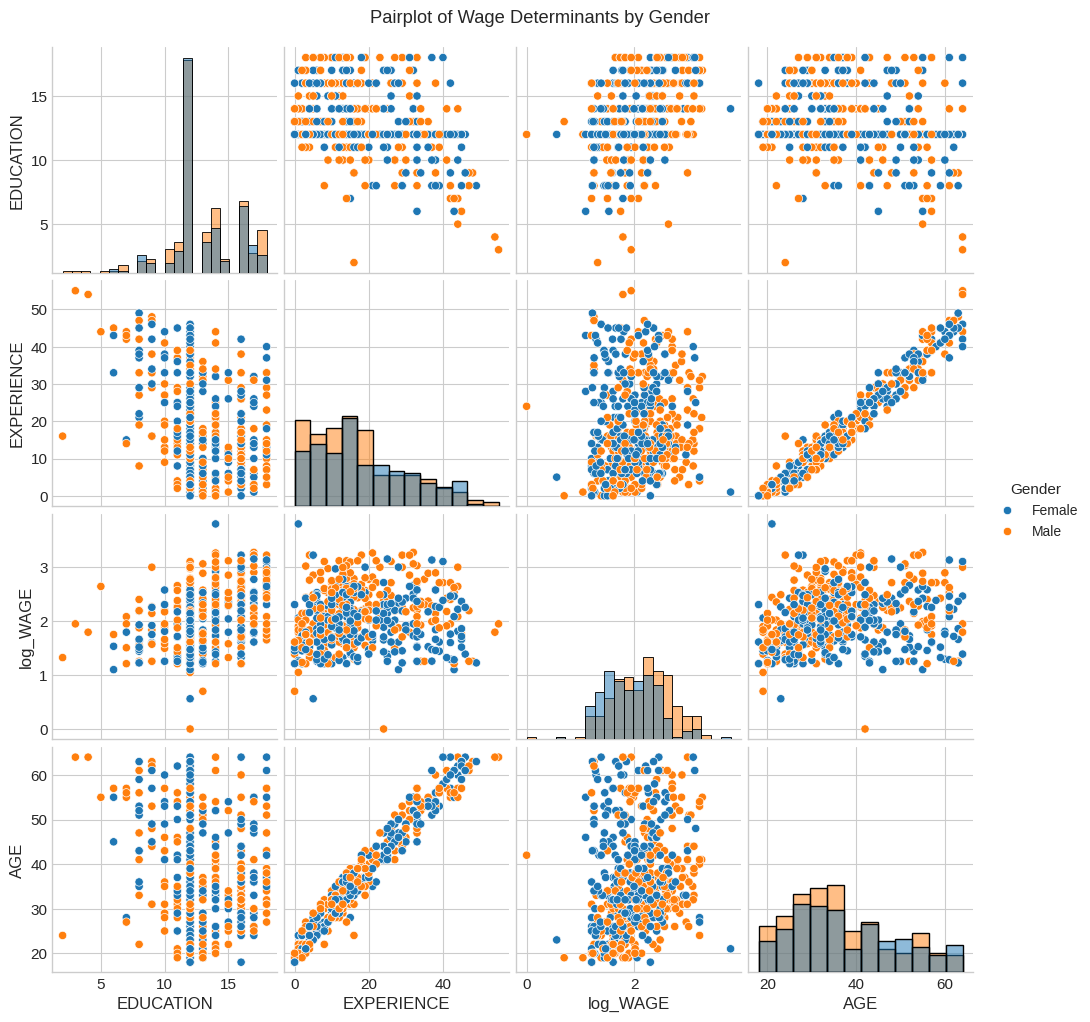

In [28]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 8),
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 1.5,
})

plot_vars = ['EDUCATION', 'EXPERIENCE', 'log_WAGE', 'AGE']
sns.pairplot(wages[plot_vars + ['Gender']], hue='Gender', diag_kind='hist', corner=False)
plt.suptitle('Pairplot of Wage Determinants by Gender', y=1.02)
plt.show()

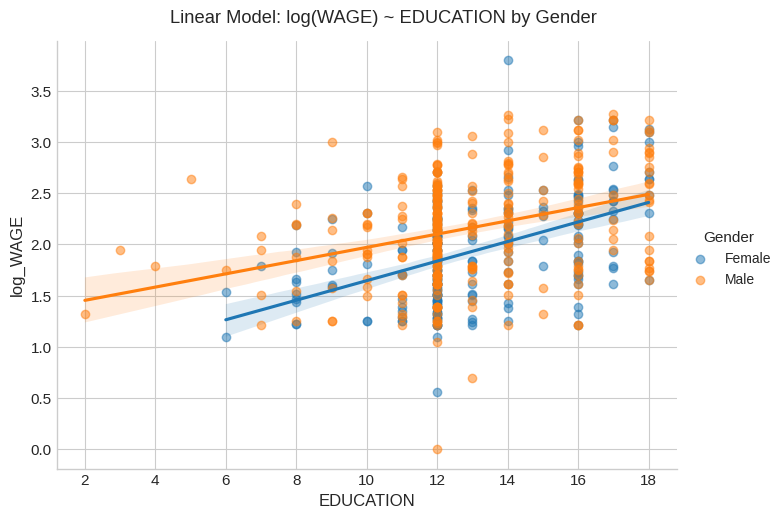

In [29]:
g = sns.lmplot(data=wages, x='EDUCATION', y='log_WAGE', hue='Gender',
               height=5, aspect=1.4, scatter_kws={'alpha': 0.5})
g.fig.suptitle('Linear Model: log(WAGE) ~ EDUCATION by Gender', y=1.03)
plt.show()

In [30]:
formula_robust = 'log_WAGE ~ EDUCATION + C(SEX)'
model_ols_wage = smf.ols(formula_robust, data=wages).fit()
model_rlm_wage = RLM.from_formula(formula_robust, data=wages, M=sm.robust.norms.HuberT()).fit()

print('OLS summary:')
print(model_ols_wage.summary())
print('\nRobust (Huber) regression summary:')
print(model_rlm_wage.summary())

OLS summary:
                            OLS Regression Results                            
Dep. Variable:               log_WAGE   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     63.42
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           2.01e-25
Time:                        00:24:18   Log-Likelihood:                -358.72
No. Observations:                 534   AIC:                             723.4
Df Residuals:                     531   BIC:                             736.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.1652      0.1

## B.5 Education–Gender Interaction with wages.txt

We compare an additive model to an interaction model to test whether the wage return to education differs between males and females.

In [31]:
model_add = smf.ols('log_WAGE ~ EDUCATION + C(SEX)', data=wages).fit()
print('Additive model: log_WAGE ~ EDUCATION + SEX')
print(model_add.summary())

Additive model: log_WAGE ~ EDUCATION + SEX
                            OLS Regression Results                            
Dep. Variable:               log_WAGE   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     63.42
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           2.01e-25
Time:                        00:24:18   Log-Likelihood:                -358.72
No. Observations:                 534   AIC:                             723.4
Df Residuals:                     531   BIC:                             736.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Int

In [32]:
model_int = smf.ols('log_WAGE ~ EDUCATION * C(SEX)', data=wages).fit()
print('Interaction model: log_WAGE ~ EDUCATION * SEX')
print(model_int.summary())

Interaction model: log_WAGE ~ EDUCATION * SEX
                            OLS Regression Results                            
Dep. Variable:               log_WAGE   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     43.72
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           2.94e-25
Time:                        00:24:18   Log-Likelihood:                -356.87
No. Observations:                 534   AIC:                             721.7
Df Residuals:                     530   BIC:                             738.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

In [33]:
print(anova_lm(model_add, model_int))

slope_male = model_int.params['EDUCATION']
interaction_term = [k for k in model_int.params.index if 'EDUCATION:C(SEX)' in k][0]
slope_female = model_int.params['EDUCATION'] + model_int.params[interaction_term]
interaction_p = model_int.pvalues[interaction_term]

print(f'\nEstimated log-wage slope for EDUCATION (Males): {slope_male:.4f}')
print(f'Estimated log-wage slope for EDUCATION (Females): {slope_female:.4f}')
print(f'Interaction p-value: {interaction_p:.4f}')

if slope_male > slope_female:
    print('Males show a larger per-year education effect on log wages than females.')
else:
    print('Females show a larger per-year education effect on log wages than males.')

if interaction_p < 0.05:
    print('The interaction is statistically significant: education benefits differ by gender.')
else:
    print('The interaction is not statistically significant at alpha=0.05.')

   df_resid         ssr  df_diff   ss_diff        F   Pr(>F)
0     531.0  119.825349      0.0       NaN      NaN      NaN
1     530.0  118.998648      1.0  0.826702  3.68199  0.05554

Estimated log-wage slope for EDUCATION (Males): 0.0647
Estimated log-wage slope for EDUCATION (Females): 0.0955
Interaction p-value: 0.0555
Females show a larger per-year education effect on log wages than males.
The interaction is not statistically significant at alpha=0.05.


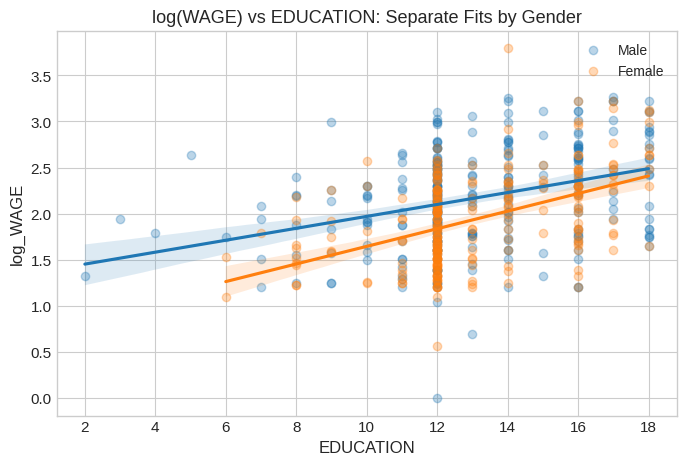

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
for sex_val, label, color in [(0, 'Male', 'tab:blue'), (1, 'Female', 'tab:orange')]:
    subset = wages[wages['SEX'] == sex_val]
    sns.regplot(data=subset, x='EDUCATION', y='log_WAGE', scatter_kws={'alpha': 0.3},
                line_kws={'color': color}, label=label, ax=ax)
ax.set_title('log(WAGE) vs EDUCATION: Separate Fits by Gender')
ax.legend()
plt.show()

**B.5 interpretation:** The interaction model allows education slopes to differ by gender. Comparing the two fitted lines and the interaction p-value tells us whether males gain more from each additional year of education than females, after allowing separate intercepts and slopes.